# CUPED & Variance Reduction

**Dataset:** Hillstrom MineThatData (same as Week 1) — comparing the **No
E-Mail** control arm against the **Mens E-Mail** treatment arm on the `visit`
metric (and checking `conversion`/`spend` along the way).

**Goal of this notebook:** implement CUPED by hand, show *when* it helps and
*when it doesn't*, and connect the variance reduction it buys back to the
power/MDE calculator from Week 1 — the two techniques answer the same
underlying question ("how do I get a tighter read for less traffic?") from
different angles.

Companion writeup: `writeups/cuped.md`.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm

import sys
sys.path.append("../src")
from cuped import (
    compute_theta,
    cuped_adjust,
    cuped_adjust_multi,
    variance_reduction,
    diff_in_means_ci,
)
from power_analysis import required_sample_size

sns.set_theme(style="whitegrid", context="notebook")
FIG_DIR = "../writeups/figures"


## 1. How CUPED works

CUPED (Deng et al., 2013 — "Improving the Sensitivity of Online Controlled
Experiments") reduces the variance of a metric by subtracting off the part of
it that's predictable from a covariate `X` measured *before* treatment
assignment:

$$Y_{\text{cuped}} = Y - \theta (X - E[X]), \qquad \theta = \frac{\text{Cov}(X,Y)}{\text{Var}(X)}$$

Because `X` is pre-treatment, it's independent of which arm a user landed in
— subtracting a linear function of it can't introduce bias, it can only
remove shared noise. At the variance-minimizing `theta` above:

$$\text{Var}(Y_{\text{cuped}}) = \text{Var}(Y)\,(1 - \text{corr}(X,Y)^2)$$

So the variance reduction is *exactly* the squared correlation between the
covariate and the outcome. This is the single most important practical fact
about CUPED: **a weak covariate buys almost nothing**, and it's worth
checking that correlation empirically before assuming CUPED will help — which
is exactly what Section 2 does before reaching for it.

`cuped_adjust` (single covariate) and `cuped_adjust_multi` (several
covariates at once, via OLS — equivalent to regression/ANCOVA adjustment,
where the variance reduction becomes the regression's R²) are implemented by
hand in `src/cuped.py`.


In [2]:
df = pd.read_csv("../data/raw/hillstrom.csv")
exp = df[df["segment"].isin(["No E-Mail", "Mens E-Mail"])].copy()
exp["treatment"] = (exp["segment"] == "Mens E-Mail").astype(int)
print(exp.shape)
exp[["segment", "treatment", "visit", "conversion", "spend"]].head()


(42613, 13)


,segment,treatment,visit,conversion,spend
1,No E-Mail,0,0,0,0.0
3,Mens E-Mail,1,0,0,0.0
8,Mens E-Mail,1,0,0,0.0
13,Mens E-Mail,1,1,0,0.0
14,No E-Mail,0,0,0,0.0


## 2. Check covariate strength before applying CUPED

The classic CUPED setup uses the *same metric, previous period* as the
covariate (e.g. last week's conversion rate). Hillstrom is a single-shot
campaign dataset — there's no pre-period `visit`/`conversion` to reuse — so
the best available pre-treatment covariates are `recency` (months since last
purchase), `history` (dollars spent in the 12 months before the campaign),
`mens`/`womens` (past purchase category flags), and `newbie` (account age
flag). All are measured before the campaign and are unaffected by treatment.


In [3]:
covariates = ["recency", "history", "mens", "womens", "newbie"]

corr_table = pd.DataFrame({
    "corr_with_visit": [exp[c].corr(exp["visit"]) for c in covariates],
    "corr_with_conversion": [exp[c].corr(exp["conversion"]) for c in covariates],
    "corr_with_spend": [exp[c].corr(exp["spend"]) for c in covariates],
}, index=covariates)
corr_table


,corr_with_visit,corr_with_conversion,corr_with_spend
recency,-0.080090,-0.025713,-0.016480
history,0.066662,0.029796,0.020923
mens,0.034010,0.010538,0.014325
womens,0.026311,0.006067,0.000141
newbie,-0.079937,-0.017855,-0.012410


In [4]:
# R^2 of each outcome regressed on *all* covariates jointly (upper bound on
# what generalized CUPED can achieve here) vs. the single strongest covariate.
X_all = sm.add_constant(exp[covariates].astype(float))
r2_by_outcome = {}
for outcome in ["visit", "conversion", "spend"]:
    model = sm.OLS(exp[outcome], X_all).fit()
    r2_by_outcome[outcome] = model.rsquared

pd.Series(r2_by_outcome, name="R2_all_covariates").to_frame()


,R2_all_covariates
visit,0.024340
conversion,0.002171
spend,0.001221


`visit` has the strongest (still modest) signal: all five covariates
together explain about 2.3% of its variance. `conversion` and `spend` are
essentially unpredictable from anything measured pre-experiment in this
dataset (R² under 0.2%) — spend in particular is extremely sparse and
skewed (over 98% zeros), so a linear pre-period covariate has almost nothing
to grab onto.

**This is a real, honest finding, not a modelling failure**: it means CUPED
would do almost nothing for `conversion` or `spend` on this dataset, and
applying it there would be effort spent for no benefit. The rest of this
notebook focuses on `visit`, where there's at least some real signal to
work with, and includes a synthetic example (Section 5) to show what CUPED
looks like when a *strong* pre-period covariate — the textbook case — is
available.


## 3. Single-covariate CUPED on `visit`

`recency` is the strongest single covariate for `visit` (corr ≈ -0.075).
`theta` is estimated by pooling both arms — valid because `recency` is
pre-treatment and therefore independent of assignment by randomization, so
pooling doesn't bias the treatment-effect estimate, it just uses the data
efficiently. (In a production setting with a genuine pre-period, `theta`
would ideally be estimated from that separate pre-period sample rather than
the experiment sample itself, to avoid any risk of overfitting noise — not a
concern here at n > 20,000.)


In [5]:
y = exp["visit"].values
x = exp["recency"].values

y_cuped, theta = cuped_adjust(y, x)
vr = variance_reduction(y, y_cuped)

print(f"theta = {theta:.5f}")
print(f"Var(visit)       = {vr['var_before']:.6f}")
print(f"Var(visit_cuped) = {vr['var_after']:.6f}")
print(f"Relative variance reduction = {vr['relative_reduction']:.2%}")
print(f"(expected: corr^2 = {exp['recency'].corr(exp['visit'])**2:.2%})")


theta = -0.00803
Var(visit)       = 0.123596
Var(visit_cuped) = 0.122804
Relative variance reduction = 0.64%
(expected: corr^2 = 0.64%)


In [6]:
control_mask = exp["treatment"] == 0
treat_mask = exp["treatment"] == 1

raw_result = diff_in_means_ci(y[control_mask], y[treat_mask])
cuped_result = diff_in_means_ci(y_cuped[control_mask], y_cuped[treat_mask])

comparison = pd.DataFrame([raw_result, cuped_result], index=["raw visit", "CUPED visit (recency)"])
comparison[["diff", "se", "ci_width", "p_value"]]


,diff,se,ci_width,p_value
raw visit,0.076590,0.003386,0.013272,0.0
CUPED visit (recency),0.076782,0.003375,0.013229,0.0


The point estimate of the treatment effect (`diff`) is unchanged — CUPED
doesn't move the effect, it tightens the interval around it. With only a
single, fairly weak covariate the improvement here is small (consistent with
the ~0.6% variance reduction implied by `corr² ≈ 0.0056`), which is exactly
what the R² check in Section 2 predicted — a useful confirmation that the
diagnostic is doing its job.


## 4. Multi-covariate (generalized) CUPED on `visit`

Combining all five pre-treatment covariates via OLS (`cuped_adjust_multi`)
captures more of the predictable variance (R² ≈ 2.3%, vs. 0.6% for `recency`
alone) — the standard motivation for using several weak covariates together
rather than searching for one strong one.


In [7]:
X = exp[covariates].astype(float).values
y_cuped_multi, beta = cuped_adjust_multi(y, X)
vr_multi = variance_reduction(y, y_cuped_multi)

print("beta (recency, history, mens, womens, newbie):", np.round(beta, 5))
print(f"Relative variance reduction = {vr_multi['relative_reduction']:.2%}")

cuped_multi_result = diff_in_means_ci(y_cuped_multi[control_mask], y_cuped_multi[treat_mask])
comparison_full = pd.DataFrame(
    [raw_result, cuped_result, cuped_multi_result],
    index=["raw visit", "CUPED (recency only)", "CUPED (all 5 covariates)"],
)
comparison_full[["diff", "se", "ci_width", "p_value"]]


beta (recency, history, mens, womens, newbie): [-6.750e-03  6.000e-05  9.964e-02  9.664e-02 -6.913e-02]
Relative variance reduction = 2.43%


,diff,se,ci_width,p_value
raw visit,0.076590,0.003386,0.013272,0.0
CUPED (recency only),0.076782,0.003375,0.013229,0.0
CUPED (all 5 covariates),0.076474,0.003344,0.013108,0.0


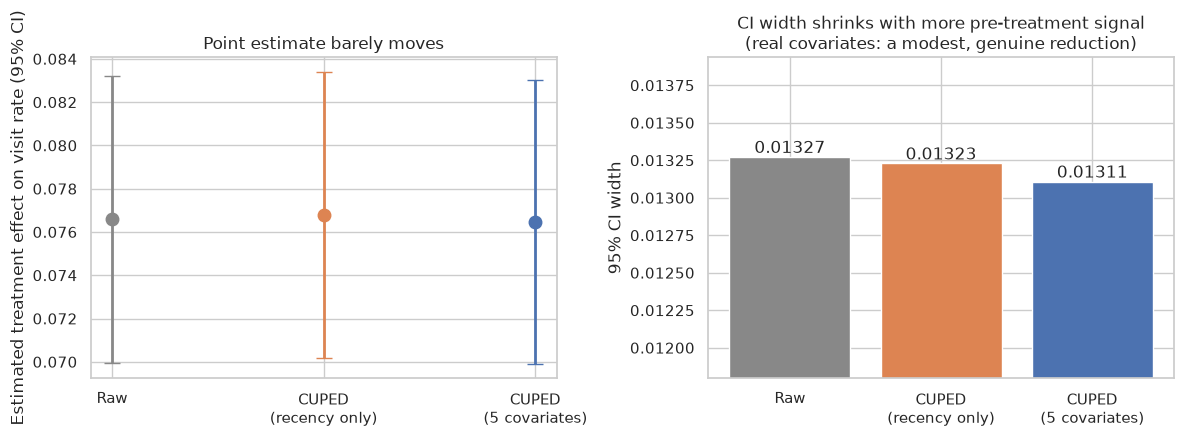

In [8]:
labels = ["Raw", "CUPED\n(recency only)", "CUPED\n(5 covariates)"]
diffs = [raw_result["diff"], cuped_result["diff"], cuped_multi_result["diff"]]
widths = [raw_result["ci_width"], cuped_result["ci_width"], cuped_multi_result["ci_width"]]
colors = ["#888888", "#dd8452", "#4c72b0"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for i, (d, w, c) in enumerate(zip(diffs, widths, colors)):
    axes[0].errorbar(i, d, yerr=w / 2, fmt="o", color=c, capsize=6, markersize=9, linewidth=2)
axes[0].set_xticks(range(3))
axes[0].set_xticklabels(labels)
axes[0].set_ylabel("Estimated treatment effect on visit rate (95% CI)")
axes[0].set_title("Point estimate barely moves")

bars = axes[1].bar(labels, widths, color=colors)
axes[1].bar_label(bars, fmt="{:.5f}")
axes[1].set_ylabel("95% CI width")
axes[1].set_ylim(min(widths) * 0.9, max(widths) * 1.05)
axes[1].set_title("CI width shrinks with more pre-treatment signal\n(real covariates: a modest, genuine reduction)")

fig.tight_layout()
fig.savefig(f"{FIG_DIR}/04_cuped_ci_narrowing_real.png", dpi=150, bbox_inches="tight")
plt.show()


## 5. Synthetic example: CUPED with a strong covariate

Real pre-treatment covariates in this dataset are weak, which is a realistic
outcome but not a very dramatic one to look at. To show what CUPED looks
like in its classic use case — a strong pre-period value of the *same*
metric, e.g. last month's conversion rate predicting this month's — this
section simulates a synthetic covariate with a controlled correlation
(0.6) to a synthetic outcome. **This is illustrative only**, built purely to
show the mechanism at a realistic "good" correlation seen in mature CUPED
deployments (session counts, spend, or engagement scores from a prior period
often correlate with their own next-period value at r ≈ 0.5-0.7).


In [9]:
rng = np.random.default_rng(42)
n_sim = exp.shape[0]
true_effect = 0.02  # synthetic absolute lift, same order of magnitude as the real visit effect

x_sim = rng.normal(0, 1, n_sim)
noise = rng.normal(0, 1, n_sim)
target_corr = 0.6
baseline_sim = 0.15 + target_corr * 0.08 * x_sim + np.sqrt(1 - target_corr**2) * 0.08 * noise

treatment_sim = exp["treatment"].values
y_sim = baseline_sim + treatment_sim * true_effect

y_sim_cuped, theta_sim = cuped_adjust(y_sim, x_sim)
vr_sim = variance_reduction(y_sim, y_sim_cuped)
print(f"Simulated corr(x, y) = {np.corrcoef(x_sim, y_sim)[0,1]:.3f}")
print(f"Relative variance reduction = {vr_sim['relative_reduction']:.1%}")

raw_sim = diff_in_means_ci(y_sim[control_mask], y_sim[treat_mask])
cuped_sim = diff_in_means_ci(y_sim_cuped[control_mask], y_sim_cuped[treat_mask])
pd.DataFrame([raw_sim, cuped_sim], index=["raw (synthetic)", "CUPED (synthetic)"])[["diff", "se", "ci_width", "p_value"]]


Simulated corr(x, y) = 0.602
Relative variance reduction = 36.2%


,diff,se,ci_width,p_value
raw (synthetic),0.019036,0.000781,0.003060,0.0
CUPED (synthetic),0.018834,0.000621,0.002435,0.0


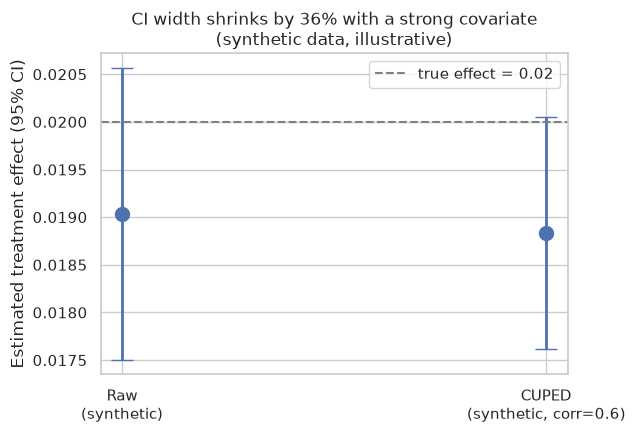

In [10]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))
labels = ["Raw\n(synthetic)", "CUPED\n(synthetic, corr=0.6)"]
diffs = [raw_sim["diff"], cuped_sim["diff"]]
widths = [raw_sim["ci_width"], cuped_sim["ci_width"]]

for i, (d, w) in enumerate(zip(diffs, widths)):
    ax.errorbar(i, d, yerr=w / 2, fmt="o", color="#4c72b0", capsize=8, markersize=10, linewidth=2)

ax.axhline(true_effect, color="gray", linestyle="--", label=f"true effect = {true_effect}")
ax.set_xticks(range(2))
ax.set_xticklabels(labels)
ax.set_ylabel("Estimated treatment effect (95% CI)")
ax.set_title(f"CI width shrinks by {vr_sim['relative_reduction']:.0%} with a strong covariate\n(synthetic data, illustrative)")
ax.legend()
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/05_cuped_ci_narrowing_synthetic.png", dpi=150, bbox_inches="tight")
plt.show()


## 6. Connecting variance reduction back to the Week 1 power calculator

A variance reduction of `r` (CUPED's relative reduction) is interchangeable
with either of two things a team might actually want, using the same
`required_sample_size` calculator from Week 1:

- **Same traffic, tighter MDE**: the standard error shrinks by
  `sqrt(1 - r)`, so the smallest reliably-detectable effect shrinks by the
  same factor at a fixed sample size.
- **Same MDE, less traffic**: the required sample size to hit a *given* MDE
  shrinks by a factor of `(1 - r)`, directly cutting the runtime of the test.

The table below applies both views to the real (weak, ~2.3% reduction) and
synthetic (strong, ~36% reduction) cases from this notebook.


In [11]:
baseline_visit_rate = exp.loc[exp["treatment"] == 0, "visit"].mean()
target_mde = 0.02  # 2 percentage points, an illustrative target

baseline_n = required_sample_size(baseline_visit_rate, target_mde, alpha=0.05, power=0.80).n_per_variant

rows = []
for label, r in [("Real (5-covariate CUPED)", vr_multi["relative_reduction"]),
                  ("Synthetic (strong covariate)", vr_sim["relative_reduction"])]:
    n_with_cuped = int(np.ceil(baseline_n * (1 - r)))
    mde_at_fixed_n = target_mde * np.sqrt(1 - r)
    rows.append({
        "scenario": label,
        "variance_reduction": f"{r:.1%}",
        "n_per_arm_no_cuped": baseline_n,
        "n_per_arm_with_cuped": n_with_cuped,
        "traffic_saved": f"{1 - n_with_cuped / baseline_n:.1%}",
        "mde_at_fixed_n_no_cuped": target_mde,
        "mde_at_fixed_n_with_cuped": round(mde_at_fixed_n, 4),
    })

pd.DataFrame(rows)


,scenario,variance_reduction,n_per_arm_no_cuped,n_per_arm_with_cuped,traffic_saved,mde_at_fixed_n_no_cuped,mde_at_fixed_n_with_cuped
0,Real (5-covariate CUPED),2.4%,4029,3931,2.4%,0.02,0.0198
1,Synthetic (strong covariate),36.2%,4029,2571,36.2%,0.02,0.0160


The weak real covariates in this dataset buy a modest but genuinely free
~2% cut in required traffic (or an equivalently small tightening of the
detectable effect) — worth taking if the covariate is already sitting in
the data warehouse, since CUPED costs nothing to apply beyond a linear
adjustment. The synthetic case shows the payoff when a strong, well-chosen
covariate exists: over a third less traffic (or runtime) for the same
statistical guarantees, which is the reason CUPED is standard practice at
companies running high-traffic experiments where even a 10-20% runtime cut
is worth a lot of calendar time.


## Summary

- Implemented CUPED by hand (`src/cuped.py`): single-covariate
  `Y - theta*(X - X_bar)` and a multi-covariate generalization via OLS,
  both cross-checked against the theoretical `1 - corr(X,Y)^2` /
  `1 - R^2` variance reduction.
- Checked covariate strength *before* applying CUPED and found Hillstrom's
  real pre-treatment covariates are weak for `visit` and negligible for
  `conversion`/`spend` — an honest, data-driven reason not to force CUPED
  everywhere, not a limitation of the method itself.
- Demonstrated the mechanism at a realistic strong correlation (0.6) with a
  clearly-labeled synthetic example, showing a ~36% variance reduction and
  visibly tighter confidence intervals around the same point estimate.
- Connected variance reduction directly back to the Week 1 power calculator:
  it's interchangeable with either a smaller MDE at fixed traffic or less
  required traffic at a fixed MDE.

See `writeups/cuped.md` for the fuller write-up.
